In [1]:
import string

import numpy as np
import pandas as pd
import scikit_posthocs as sp
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors

from scipy import stats
from pathlib import Path
from itertools import combinations
from scipy.stats import kruskal, shapiro, f_oneway, ttest_rel
from matplotlib.patches import Patch, Rectangle
from matplotlib.legend_handler import HandlerBase
from statsmodels.stats.multicomp import pairwise_tukeyhsd
from mpl_toolkits.axes_grid1.inset_locator import inset_axes, mark_inset

## Data Preprocessing

In [2]:
df_base = pd.read_csv('./data/Attack-B-Results.csv')
df_base.head()

,model,Clean_IM_Loss,BIM_IM_Loss,Clean_LA_Loss,BIM_LA_Loss
0,1V,0.007276,0.086683,NaN,NaN
1,1V,0.007288,0.096850,NaN,NaN
2,1V,0.007914,0.078398,NaN,NaN
3,1V,0.008287,0.091447,NaN,NaN
4,1V,0.007602,0.081851,NaN,NaN


In [3]:
df_test = df_base.copy().reset_index(drop=True)

df_test['BIM_IM_Abs_Increase'] = (
    df_test['BIM_IM_Loss'] - df_test['Clean_IM_Loss']
)

df_test['BIM_IM_Rel_Increase'] = (
    df_test['BIM_IM_Abs_Increase'] / df_test['Clean_IM_Loss'] * 100
)

df_test

,model,Clean_IM_Loss,BIM_IM_Loss,Clean_LA_Loss,BIM_LA_Loss,BIM_IM_Abs_Increase,BIM_IM_Rel_Increase
0,1V,0.007276,0.086683,NaN,NaN,0.079408,1091.431496
1,1V,0.007288,0.096850,NaN,NaN,0.089562,1228.927485
2,1V,0.007914,0.078398,NaN,NaN,0.070484,890.628816
3,1V,0.008287,0.091447,NaN,NaN,0.083159,1003.441361
4,1V,0.007602,0.081851,NaN,NaN,0.074249,976.694555
5,1V,0.007812,0.090300,NaN,NaN,0.082487,1055.852460
6,1V,0.007724,0.102969,NaN,NaN,0.095245,1233.079373
7,1V,0.008155,0.107993,NaN,NaN,0.099839,1224.317223
8,1V,0.008127,0.116235,NaN,NaN,0.108108,1330.178752
9,1V,0.007930,0.007930,NaN,NaN,0.000000,0.000000


In [4]:
df_mean = (
    df_test
        .groupby(['model'], as_index=False)[['Clean_IM_Loss', 'BIM_IM_Loss', 'BIM_IM_Abs_Increase', 'BIM_IM_Rel_Increase']]
        .mean()
        .round(3)
        .reset_index()
)

df_mean

,index,model,Clean_IM_Loss,BIM_IM_Loss,BIM_IM_Abs_Increase,BIM_IM_Rel_Increase
0,0,1V,0.008,0.086,0.078,1003.455
1,1,2V,0.009,0.083,0.074,841.372


## Plots

In [5]:
model_order = ['1V', '2V']

model_color_map = {
    '1V': 'tab:blue',
    '2V': 'tab:orange',
}

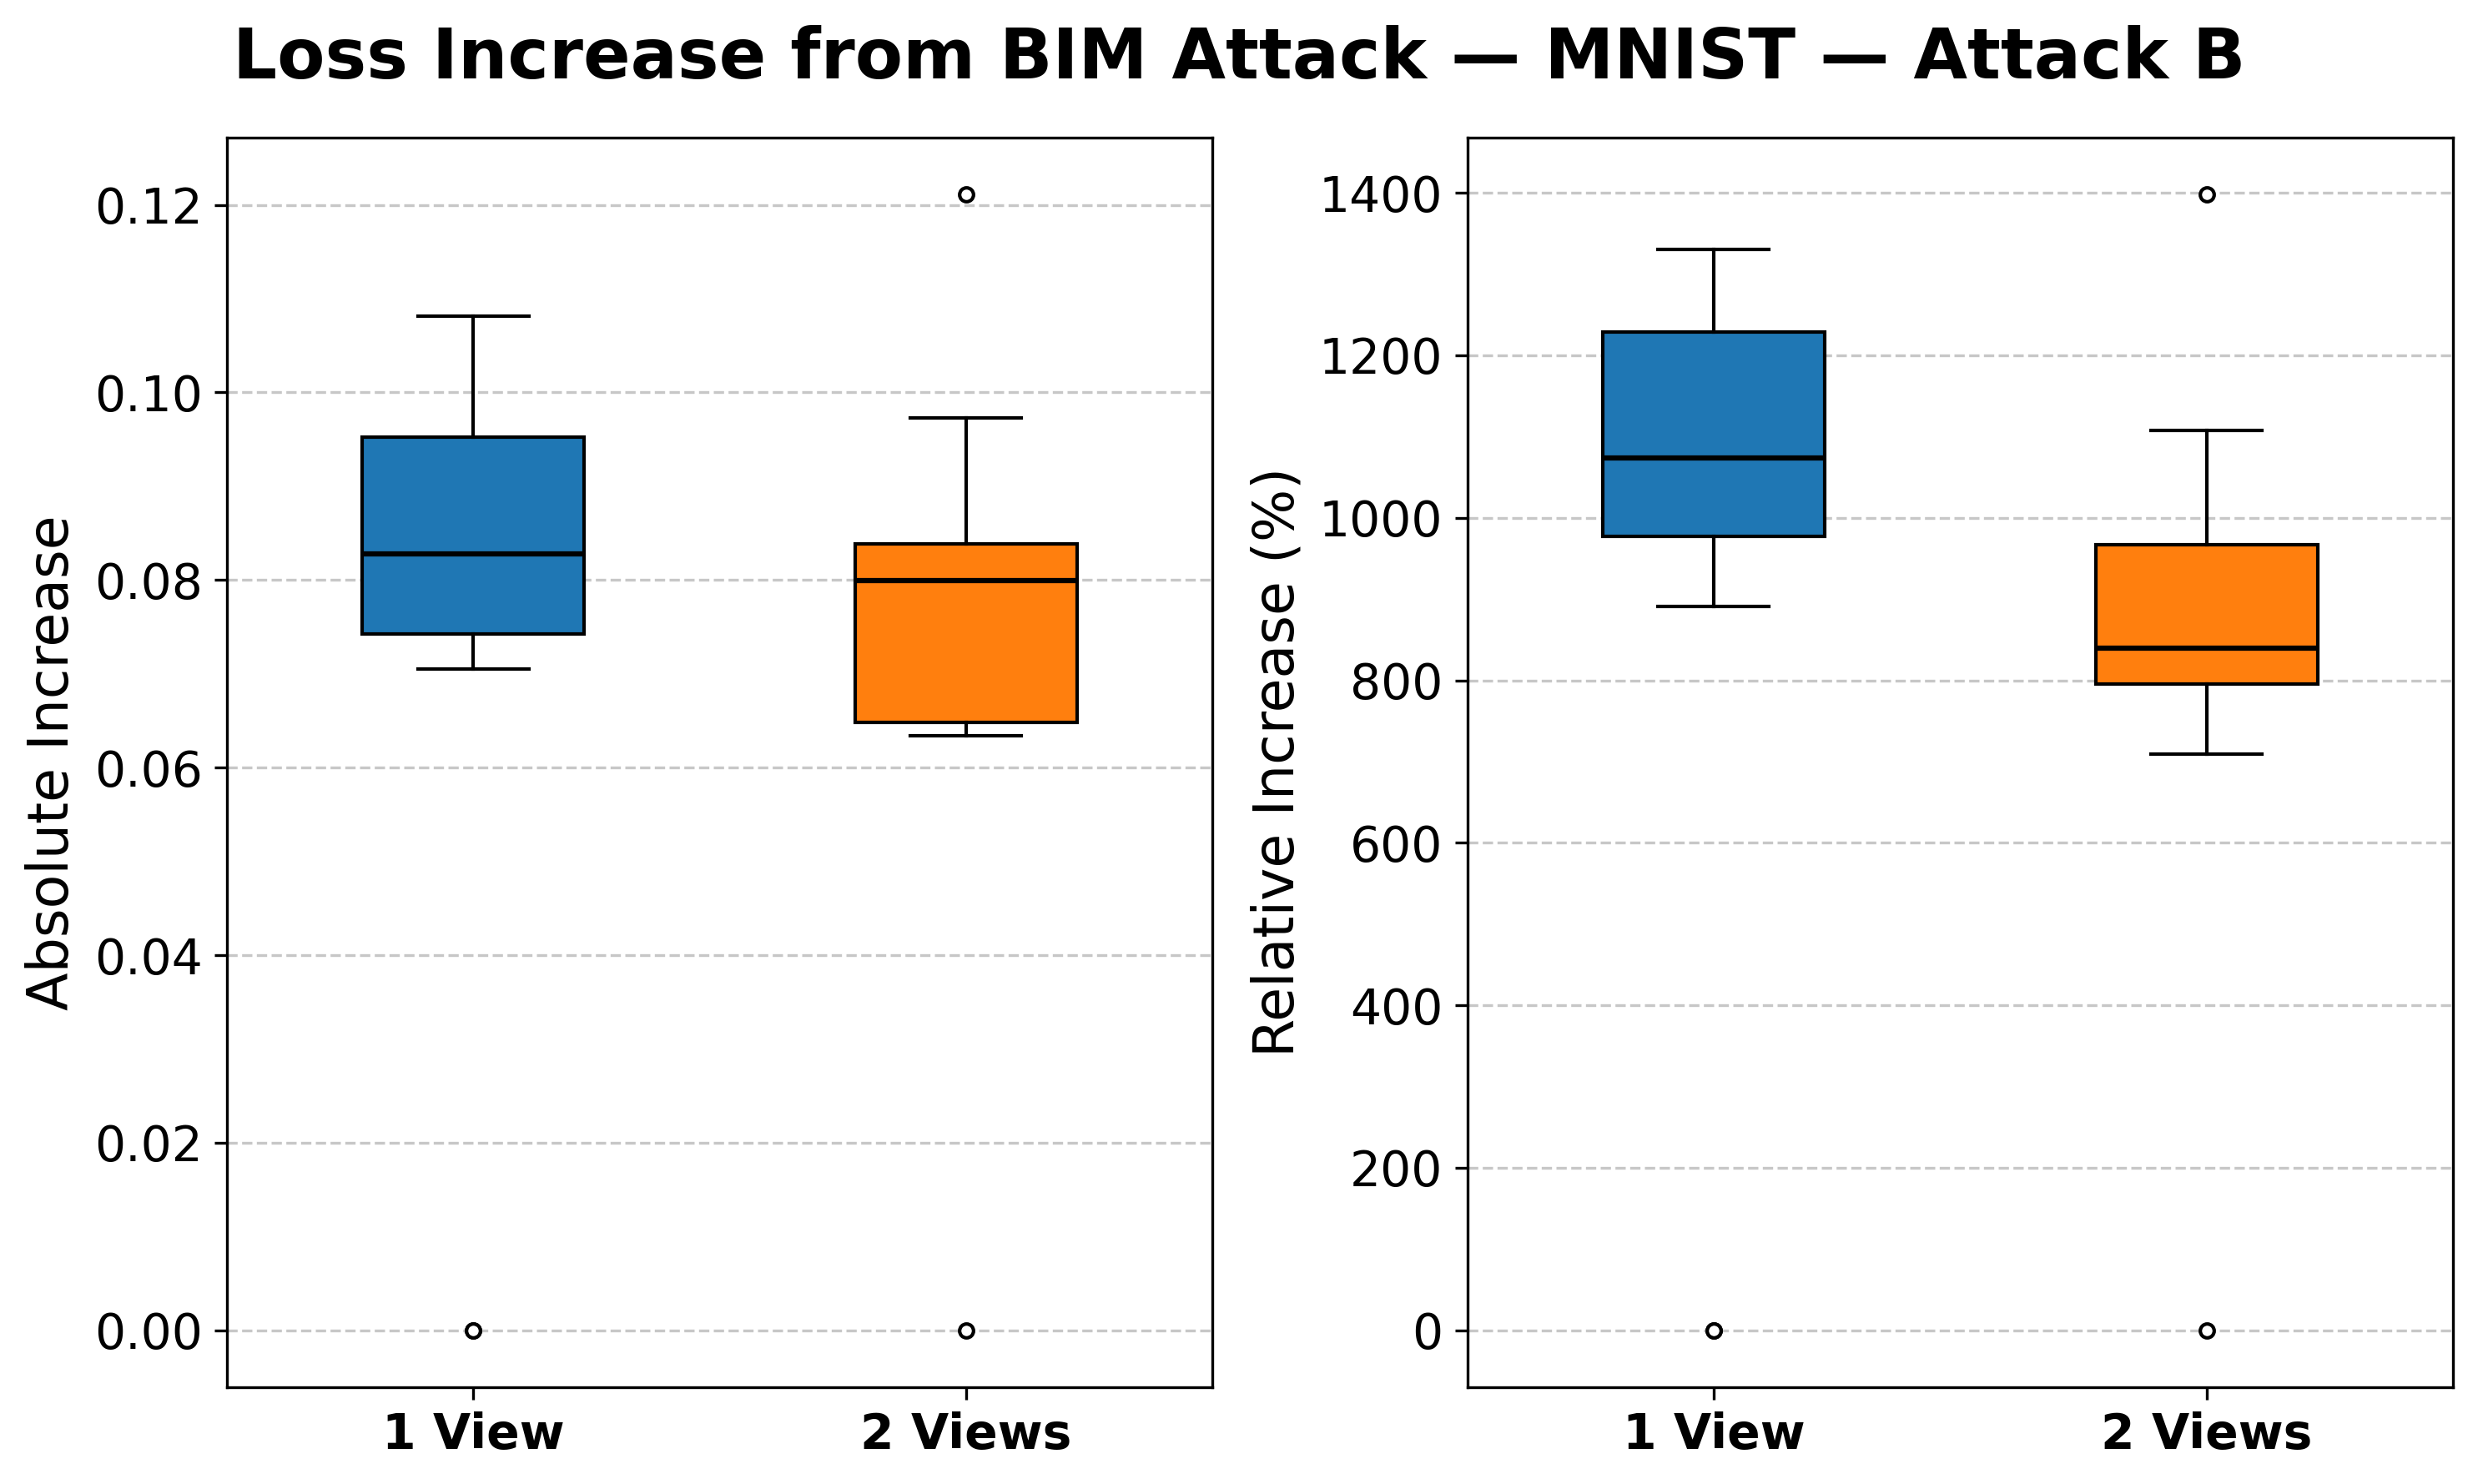

In [6]:
model_label_map = {
    '1V': '1 View',
    '2V': '2 Views',
}

fig, axes = plt.subplots(1, 2, figsize=(10, 6), dpi=300)

plot_specs = [
    (
        'BIM_IM_Abs_Increase',
        'Absolute Increase',
        'Absolute Image Loss Increase',
    ),
    (
        'BIM_IM_Rel_Increase',
        'Relative Increase (%)',
        'Relative Image Loss Increase',
    ),
]

model_positions = np.arange(len(model_order))

for ax, (col, ylabel, title) in zip(axes, plot_specs):
    values = [
        df_test.loc[df_test['model'].eq(model), col].dropna().to_numpy()
        for model in model_order
    ]

    box = ax.boxplot(
        values,
        positions=model_positions,
        widths=0.45,
        patch_artist=True,
        showfliers=True,
    )

    for patch, model in zip(box['boxes'], model_order):
        patch.set_facecolor(model_color_map[model])
        patch.set_edgecolor('black')

    for median in box['medians']:
        median.set_color('black')
        median.set_linewidth(1.5)

    for whisker in box['whiskers']:
        whisker.set_color('black')

    for cap in box['caps']:
        cap.set_color('black')

    for flier in box['fliers']:
        flier.set_marker('o')
        flier.set_markerfacecolor('white')
        flier.set_markeredgecolor('black')
        flier.set_markersize(4)

    ax.set_ylabel(ylabel, fontsize=16)

    ax.set_xticks(model_positions)
    ax.set_xticklabels(
        [model_label_map.get(model, model) for model in model_order],
        fontsize=14,
        fontweight='bold'
    )

    ax.tick_params(axis='y', labelsize=14)

    ax.grid(axis='y', linestyle='--', alpha=0.7)
    ax.set_axisbelow(True)

plt.suptitle('Loss Increase from BIM Attack — MNIST — Attack B', fontsize=20, fontweight='bold')
plt.tight_layout()
plt.savefig('./img/attack-B-image-loss-increases-boxplots.png', bbox_inches='tight')
plt.show()

## Statistical Tests - Attacks

In [7]:
loss_cols = [
    'Clean_IM_Loss',
    'BIM_IM_Loss',
]

In [8]:
pairwise_results = []

for col1, col2 in combinations(loss_cols, 2):
    paired_data = df_test[[col1, col2]].dropna()

    t_stat, p_value = ttest_rel(
        paired_data[col1],
        paired_data[col2],
    )

    pairwise_results.append({
        'test': 'Paired t-test',
        'comparison': f'{col1} vs {col2}',
        'n': len(paired_data),
        't-statistic': t_stat,
        'p-value': p_value,
        'significant': p_value < 0.05,
    })

ttest_results = pd.DataFrame(pairwise_results)

ttest_results

,test,comparison,n,t-statistic,p-value,significant
0,Paired t-test,Clean_IM_Loss vs BIM_IM_Loss,30,-14.348099,1.050724e-14,True


## Statistical Tests
### Normality

In [9]:
test_cols = [
    'BIM_IM_Loss',
    'BIM_IM_Abs_Increase',
    'BIM_IM_Rel_Increase',
]

In [10]:
normality_results = []

for col in test_cols:
    print(f'\n===== {col} =====')

    for model in model_order:
        values = (
            df_test
            .loc[df_test['model'].eq(model), col]
            .dropna()
            .to_numpy()
        )

        w_stat, p_value = shapiro(values)

        normality_results.append({
            'metric': col,
            'model': model,
            'W': w_stat,
            'p': p_value,
            'normal': p_value > 0.05,
        })

        print(f'{model}: W = {w_stat:.4f}, p = {p_value:.4f}')

normality_df = pd.DataFrame(normality_results)
normality_df


===== BIM_IM_Loss =====
1V: W = 0.7277, p = 0.0001
2V: W = 0.8694, p = 0.0983

===== BIM_IM_Abs_Increase =====
1V: W = 0.7236, p = 0.0001
2V: W = 0.8647, p = 0.0867

===== BIM_IM_Rel_Increase =====
1V: W = 0.6887, p = 0.0000
2V: W = 0.8607, p = 0.0777


,metric,model,W,p,normal
0,BIM_IM_Loss,1V,0.727658,0.000086,False
1,BIM_IM_Loss,2V,0.869381,0.098319,True
2,BIM_IM_Abs_Increase,1V,0.723606,0.000077,False
3,BIM_IM_Abs_Increase,2V,0.864695,0.086658,True
4,BIM_IM_Rel_Increase,1V,0.688661,0.000028,False
5,BIM_IM_Rel_Increase,2V,0.860667,0.077704,True


### Significance

In [11]:
ttest_results = []

df_paired = df_test.copy()

# Creates pair index: 0, 1, 2, ... separately for each model
df_paired['run'] = df_paired.groupby('model').cumcount()

for col in test_cols:
    wide_df = (
        df_paired
        .pivot(index='run', columns='model', values=col)
        .dropna(subset=model_order)
    )

    t_stat, p_value = ttest_rel(
        wide_df[model_order[0]],
        wide_df[model_order[1]],
        nan_policy='omit',
    )

    ttest_results.append({
        'metric': col,
        'group_1': model_order[0],
        'group_2': model_order[1],
        't': t_stat,
        'p': p_value,
        'significant': p_value < 0.05,
    })

    print(f'\n===== {col} =====')
    print(f'{model_order[0]} vs {model_order[1]}')
    print(f'n pairs: {len(wide_df)}')
    print(f't-statistic: {t_stat:.6f}')
    print(f'p-value: {p_value:.6e}')

ttest_df = pd.DataFrame(ttest_results)
ttest_df


===== BIM_IM_Loss =====
1V vs 2V
n pairs: 10
t-statistic: 0.546255
p-value: 5.981689e-01

===== BIM_IM_Abs_Increase =====
1V vs 2V
n pairs: 10
t-statistic: 0.710113
p-value: 4.956207e-01

===== BIM_IM_Rel_Increase =====
1V vs 2V
n pairs: 10
t-statistic: 2.132176
p-value: 6.180246e-02


,metric,group_1,group_2,t,p,significant
0,BIM_IM_Loss,1V,2V,0.546255,0.598169,False
1,BIM_IM_Abs_Increase,1V,2V,0.710113,0.495621,False
2,BIM_IM_Rel_Increase,1V,2V,2.132176,0.061802,False
